# ResNet — He et al. (2015), explained

Paper: *Deep Residual Learning for Image Recognition*.

Goal of this notebook: **understand residual learning and ResNet architecture**, not to build a framework.
Anything PyTorch already provides (`nn.Conv2d`, `nn.BatchNorm2d`, `CrossEntropyLoss`, `SGD`, `DataLoader`) is used as-is.

Here the paper's ImageNet task is swapped for **individual tiger identification** on the
[ATRW](https://cvwc2019.github.io/challenge.html) re-ID dataset: given a photo of a tiger, name
*which* of 107 known tigers it is.

**Layout**
1. Load the data
2. Helper functions, and why each one exists
3. The architecture — every layer, and the training step line by line
4. Train
5. Predict and validate
6. Glossary

**What the paper specifies** (kept): residual blocks, identity/projection shortcuts, batch normalization,
ReLU non-linearity, global average pooling, and SGD optimization.

**Where this adapts** (two places, on purpose):
- Paper's output is 1000 ImageNet classes. Here: output is **107 tiger identities**.
- Paper reports very deep variants (34/50/101/152). Here we use a smaller **ResNet-18 style** model
  so training is practical on this dataset and hardware.

# Section 1 — Loading the data

**ATRW (Amur Tiger Re-identification in the Wild), reid split**: photos of Amur tigers cropped
around the animal, each tagged with the identity of the tiger in it.

```
benchmarks/atrw_dataset_reid_tiger/
├── atrw_anno_reid_train/reid_list_train.csv   id, filename  (labelled)
├── atrw_reid_train/train/*.jpg                labelled + extra unlabelled crops
├── atrw_anno_reid_test/reid_list_test.csv     filename only (no id — used for the
│                                               official retrieval leaderboard, not
│                                               classification, so it's no use here)
└── atrw_reid_test/test/*.jpg
```

Two details this notebook works around:
- The train **folder** has extra unlabelled crops, but the train **CSV** labels only 1,887 rows.
  We use only labelled rows.
- The official test CSV has no identity labels. So "test" here means a held-out **validation
  split carved out of the labelled training rows** (stratified by tiger id), not the
  `atrw_reid_test` folder.

ResNet in the paper uses random crops/flips and per-channel normalization. We follow that style:
- **Train transform:** resize short side, random crop to 224, random horizontal flip.
- **Validation transform:** deterministic center crop to 224.
- **Normalize:** channel-wise normalization for stable optimization.

In [5]:
import csv
import os
from pathlib import Path

import torch
from torch import nn
import torch.nn.functional as F
from PIL import Image, ImageFile
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

# Prevent worker crashes on partially corrupted JPEG files.
ImageFile.LOAD_TRUNCATED_IMAGES = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True

torch.manual_seed(0)

DATA_ROOT = Path("benchmarks/atrw_dataset_reid_tiger")
TRAIN_IMG_DIR = DATA_ROOT / "atrw_reid_train" / "train"
TRAIN_CSV = DATA_ROOT / "atrw_anno_reid_train" / "reid_list_train.csv"

print("torch", torch.__version__, "| device:", DEVICE)

torch 2.12.1+cu126 | device: cuda


In [6]:
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])


def read_labels(csv_path):
    """CSV rows are 'id,filename' -> [(filename, id), ...]."""
    rows = []
    with open(csv_path, newline="") as f:
        for tiger_id, filename in csv.reader(f):
            rows.append((filename, int(tiger_id)))
    return rows


class TigerReIDDataset(Dataset):
    """One row = one photo of one tiger. Loads and transforms lazily."""

    def __init__(self, samples, img_dir, class_to_idx, transform):
        self.samples = samples
        self.img_dir = img_dir
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        filename, tiger_id = self.samples[i]
        img = Image.open(self.img_dir / filename).convert("RGB")
        return self.transform(img), self.class_to_idx[tiger_id]


def stratified_split(rows, val_fraction=0.15, seed=0):
    """Hold out val_fraction of each tiger's photos to preserve class coverage."""
    import random

    by_id = {}
    for filename, tiger_id in rows:
        by_id.setdefault(tiger_id, []).append(filename)

    rng = random.Random(seed)
    train_rows, val_rows = [], []
    for tiger_id, files in by_id.items():
        files = files[:]
        rng.shuffle(files)
        n_val = max(1, round(len(files) * val_fraction))
        for f in files[:n_val]:
            val_rows.append((f, tiger_id))
        for f in files[n_val:]:
            train_rows.append((f, tiger_id))
    return train_rows, val_rows


def load_data():
    rows = read_labels(TRAIN_CSV)
    tiger_ids = sorted({tiger_id for _, tiger_id in rows})
    class_to_idx = {tid: i for i, tid in enumerate(tiger_ids)}

    train_rows, val_rows = stratified_split(rows, val_fraction=0.15)
    tr = TigerReIDDataset(train_rows, TRAIN_IMG_DIR, class_to_idx, train_transform)
    te = TigerReIDDataset(val_rows, TRAIN_IMG_DIR, class_to_idx, val_transform)
    return tr, te, len(tiger_ids)

In [7]:
train_ds, test_ds, N_CLASSES = load_data()

print(f"{N_CLASSES} tiger identities | train: {len(train_ds)}  val/'test': {len(test_ds)}")
x0, y0 = train_ds[0]
print("one sample:", tuple(x0.shape), "label", int(y0),
      "| pixel range", float(x0.min()), "to", float(x0.max()))

107 tiger identities | train: 1588  val/'test': 299
one sample: (3, 224, 224) label 93 | pixel range -1.0904186964035034 to 1.9776908159255981


In [8]:
# DataLoader = batching + shuffling + parallel data loading.
BATCH = 64
PIN_MEMORY = DEVICE.type == "cuda"

# Windows notebooks can be unstable with many worker subprocesses.
if os.name == "nt":
    NUM_WORKERS = 0
else:
    NUM_WORKERS = min(8, os.cpu_count() or 1)


def make_loaders(num_workers):
    common = dict(
        num_workers=num_workers,
        pin_memory=PIN_MEMORY,
        persistent_workers=num_workers > 0,
    )
    tr_loader = DataLoader(
        train_ds,
        batch_size=BATCH,
        shuffle=True,
        **common,
    )
    te_loader = DataLoader(
        test_ds,
        batch_size=256,
        shuffle=False,
        **common,
    )
    return tr_loader, te_loader


train_loader, test_loader = make_loaders(NUM_WORKERS)

# Probe one batch; if worker mode fails, fall back to single-process loading.
try:
    xb, yb = next(iter(train_loader))
except RuntimeError as e:
    if "DataLoader worker" in str(e):
        NUM_WORKERS = 0
        train_loader, test_loader = make_loaders(NUM_WORKERS)
        xb, yb = next(iter(train_loader))
        print("worker crash detected -> fallback to num_workers=0")
    else:
        raise

print("one batch:", tuple(xb.shape), "labels", tuple(yb.shape))
print("num_workers:", NUM_WORKERS, "| pin_memory:", PIN_MEMORY)

one batch: (64, 3, 224, 224) labels (64,)
num_workers: 0 | pin_memory: True


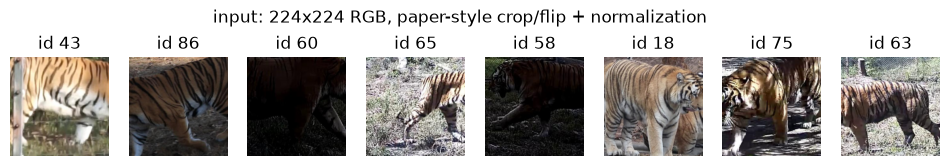

In [9]:
# Look at what we're feeding the network.
import matplotlib.pyplot as plt


def unnormalize(img):
    """(3,H,W) normalized tensor -> (H,W,3) array in 0..1, for display only."""
    mean = torch.tensor(NORM_MEAN).view(3, 1, 1)
    std = torch.tensor(NORM_STD).view(3, 1, 1)
    return (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax, img, lab in zip(axes, xb, yb):
    ax.imshow(unnormalize(img)); ax.set_title(f"id {int(lab)}"); ax.axis("off")
plt.suptitle("input: 224x224 RGB, paper-style crop/flip + normalization")
plt.show()

# Section 2 — Helper functions, and why each exists

Four small helpers. Each answers one question you will ask while iterating.

In [10]:
def count_params(model):
    """WHY: capacity vs. speed. Deeper/wider nets fit more but train slower."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


@torch.no_grad()
def accuracy(model, loader):
    """WHY: held-out accuracy is the key metric for identity classification."""
    model.eval()
    correct = total = 0
    for x, y in loader:
        pred = model(x.to(DEVICE, non_blocking=True)).argmax(1).cpu()
        correct += (pred == y).sum().item()
        total += len(y)
    return 100.0 * correct / total


@torch.no_grad()
def show_shapes(model, size=224, channels=3):
    """WHY: verify shape flow through residual stages and downsampling points."""
    x = torch.zeros(1, channels, size, size, device=DEVICE)
    print(f"{'input':28} {tuple(x.shape)}")

    hooks = []

    def register(name, module):
        if len(list(module.children())) == 0:
            def hook(_m, _in, out):
                del _m, _in
                if isinstance(out, torch.Tensor):
                    print(f"{name:28} {tuple(out.shape)}")
            hooks.append(module.register_forward_hook(hook))

    for name, module in model.named_modules():
        register(name, module)

    model.eval()
    _ = model(x)

    for h in hooks:
        h.remove()


def plot_history(history):
    """WHY: curve shape tells if we are underfitting, overfitting, or still improving."""
    _, ax = plt.subplots(1, 2, figsize=(11, 3.5))
    ax[0].plot([h["train_loss"] for h in history], marker="o")
    ax[0].set_title("training loss"); ax[0].set_xlabel("epoch")
    ax[1].plot([h["train_acc"] for h in history], marker="o", label="train")
    ax[1].plot([h["test_acc"] for h in history], marker="o", label="test")
    ax[1].set_title("accuracy (%)"); ax[1].set_xlabel("epoch"); ax[1].legend()
    plt.tight_layout(); plt.show()

# Section 3 — The architecture

## The shape of the idea

ResNet learns a **residual function** instead of a full mapping.
For a block input $x$, the paper rewrites the target as:

$$
y = F(x, W) + x
$$

where $F$ is the stacked convolution path and $x$ is the shortcut (identity if shapes match,
projection if channel/stride changes).

This makes deep networks easier to optimize than plain stacks of layers.

## The layers (ResNet-18 style)

| Stage | What it is | In → Out | Why |
|---|---|---|---|
| stem | 7×7 conv, stride 2 + BN + ReLU + 3×3 max-pool | 3×224×224 → 64×56×56 | early feature extraction + downsampling |
| layer1 | 2 residual blocks, 64 channels | 64×56×56 → 64×56×56 | local feature learning without size change |
| layer2 | 2 residual blocks, first block stride 2 | 64×56×56 → 128×28×28 | deeper features + spatial downsampling |
| layer3 | 2 residual blocks, first block stride 2 | 128×28×28 → 256×14×14 | higher-level structure |
| layer4 | 2 residual blocks, first block stride 2 | 256×14×14 → 512×7×7 | strongest semantic features |
| head | global average pooling + fully connected | 512×7×7 → 107 | one score per tiger identity |

Inside each basic residual block:
- conv 3×3 + BN + ReLU
- conv 3×3 + BN
- add shortcut
- ReLU

Only the final classifier size changes from the paper setup (1000 → 107 classes).

In [11]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        # Projection shortcut (paper option B) when shape changes.
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = self.relu(out)
        return out


class ResNet(nn.Module):
    def __init__(self, block, layers, n_classes=107):
        super().__init__()
        self.in_channels = 64

        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        self.layer1 = self._make_layer(block, 64, layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, n_classes)

    def _make_layer(self, block, out_channels, blocks, stride):
        layers = [block(self.in_channels, out_channels, stride=stride)]
        self.in_channels = out_channels * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


def resnet18(n_classes):
    return ResNet(BasicBlock, [2, 2, 2, 2], n_classes=n_classes)


model = resnet18(n_classes=N_CLASSES).to(DEVICE)
print(model)
print("\ntrainable parameters:", count_params(model), "(ResNet-18 style)")

ResNet(
  (stem): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (shortcut): Identity()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentu

In [12]:
# Watch the tensor flow through stem and residual stages.
show_shapes(model);

input                        (1, 3, 224, 224)
stem.0                       (1, 64, 112, 112)
stem.1                       (1, 64, 112, 112)
stem.2                       (1, 64, 112, 112)
stem.3                       (1, 64, 56, 56)
layer1.0.shortcut            (1, 64, 56, 56)
layer1.0.conv1               (1, 64, 56, 56)
layer1.0.bn1                 (1, 64, 56, 56)
layer1.0.relu                (1, 64, 56, 56)
layer1.0.conv2               (1, 64, 56, 56)
layer1.0.bn2                 (1, 64, 56, 56)
layer1.0.relu                (1, 64, 56, 56)
layer1.1.shortcut            (1, 64, 56, 56)
layer1.1.conv1               (1, 64, 56, 56)
layer1.1.bn1                 (1, 64, 56, 56)
layer1.1.relu                (1, 64, 56, 56)
layer1.1.conv2               (1, 64, 56, 56)
layer1.1.bn2                 (1, 64, 56, 56)
layer1.1.relu                (1, 64, 56, 56)
layer2.0.shortcut.0          (1, 128, 28, 28)
layer2.0.shortcut.1          (1, 128, 28, 28)
layer2.0.conv1               (1, 128, 28, 28)


## What one training step actually does

Five lines, run once per batch. This is the whole of "learning".

```python
scores = model(x)                 # 1. FORWARD
loss   = criterion(scores, y)     # 2. MEASURE THE ERROR
optimizer.zero_grad()             # 3. CLEAR OLD GRADIENTS
loss.backward()                   # 4. BACKWARD  (back-propagation)
optimizer.step()                  # 5. UPDATE THE WEIGHTS
```

**1. Forward.** The batch flows through stem + residual stages and comes out as
107 logits per image.

**2. Loss.** `CrossEntropyLoss` compares logits against true classes and returns one
scalar error.

**3. Zero the gradients.** PyTorch accumulates gradients into `.grad` by default.

**4. Backward — back-propagation.** Gradients of all parameters are computed via chain rule.

**5. Update.** SGD updates weights in the direction that reduces loss.

Repeat over the whole dataset = one **epoch**.

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=1e-4)

x, y = next(iter(train_loader))
x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)

# Pick one stem kernel weight and watch it change.
w = model.stem[0].weight
before = w[0, 0, 0, 0].item()
print("gradient before backward():", w.grad)

scores = model(x)
print("scores for one image (first 10 of", N_CLASSES, "):",
      scores[0, :10].detach().cpu().numpy().round(3))

loss = criterion(scores, y)
print("loss:", round(loss.item(), 4))

optimizer.zero_grad()
loss.backward()
print("gradient after backward():", round(w.grad[0, 0, 0, 0].item(), 6))

optimizer.step()
print(f"weight: {before:.6f} -> {w[0,0,0,0].item():.6f}  (moved against the gradient)")

gradient before backward(): None
scores for one image (first 10 of 107 ): [ 0.072  0.024  0.011  0.032 -0.023 -0.03  -0.045  0.052 -0.007 -0.016]
loss: 4.6748
gradient after backward(): -5.2e-05
weight: -0.001799 -> -0.001794  (moved against the gradient)


# Section 4 — Training

Same five lines, now in a loop over epochs.

Paper-consistent choices used here:
- SGD with momentum
- weight decay
- learning-rate drops during training

For speed on GPU, mixed precision (`autocast` + `GradScaler`) is enabled automatically.

In [ ]:
def fit(model, train_loader, test_loader, epochs=30, lr=0.1):
    """Train the model. Returns a history list you can plot."""
    import csv, time
    from pathlib import Path

    log_path = Path("runs") / "n4_Resnet" / "history.csv"
    log_path.parent.mkdir(parents=True, exist_ok=True)

    def log_epoch_csv(rec):
        """Append one epoch's metrics as a CSV row -- survives a KeyboardInterrupt mid-training."""
        write_header = not log_path.exists()
        with open(log_path, "a", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=list(rec.keys()))
            if write_header:
                writer.writeheader()
            writer.writerow(rec)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[15, 24], gamma=0.1)

    amp_enabled = DEVICE.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)

    history = []

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()
        model.train()
        running_loss, correct, seen = 0.0, 0, 0

        for x, y in train_loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=amp_enabled):
                scores = model(x)
                loss = criterion(scores, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * len(y)
            correct += (scores.argmax(1) == y).sum().item()
            seen += len(y)

        scheduler.step()

        test_acc = accuracy(model, test_loader)
        rec = {
            "epoch": epoch,
            "train_loss": running_loss / seen,
            "train_acc": 100.0 * correct / seen,
            "test_acc": test_acc,
            "error_rate": round(100.0 - test_acc, 4),
            "epoch_time_sec": round(time.time() - epoch_start, 2),
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(rec)
        log_epoch_csv(rec)
        print(
            f"epoch {epoch:2d}  lr {rec['lr']:.4g}  loss {rec['train_loss']:.4f}  "
            f"train {rec['train_acc']:.2f}%  test {rec['test_acc']:.2f}%  "
            f"({rec['epoch_time_sec']:.1f}s)"
        )

    return history

In [16]:
model = resnet18(n_classes=N_CLASSES).to(DEVICE)     # fresh model
history = fit(model, train_loader, test_loader, epochs=40, lr=0.1)

epoch  1  lr 0.1  loss 5.2971  train 7.12%  test 1.00%
epoch  2  lr 0.1  loss 3.8034  train 12.97%  test 10.70%
epoch  3  lr 0.1  loss 3.1832  train 17.25%  test 15.05%
epoch  4  lr 0.1  loss 2.8483  train 20.84%  test 23.75%
epoch  5  lr 0.1  loss 2.6107  train 24.75%  test 25.75%
epoch  6  lr 0.1  loss 2.4915  train 26.83%  test 33.44%
epoch  7  lr 0.1  loss 2.3567  train 29.85%  test 30.77%
epoch  8  lr 0.1  loss 2.1148  train 34.95%  test 38.80%
epoch  9  lr 0.1  loss 2.0175  train 38.54%  test 42.47%
epoch 10  lr 0.1  loss 1.8657  train 42.76%  test 44.15%
epoch 11  lr 0.1  loss 1.7784  train 45.34%  test 47.83%
epoch 12  lr 0.1  loss 1.5805  train 49.75%  test 39.46%
epoch 13  lr 0.1  loss 1.5820  train 48.93%  test 51.17%
epoch 14  lr 0.1  loss 1.3996  train 55.73%  test 61.20%
epoch 15  lr 0.01  loss 1.3287  train 57.12%  test 55.52%
epoch 16  lr 0.01  loss 1.0736  train 66.69%  test 69.23%
epoch 17  lr 0.01  loss 0.8719  train 72.67%  test 74.58%
epoch 18  lr 0.01  loss 0.8561

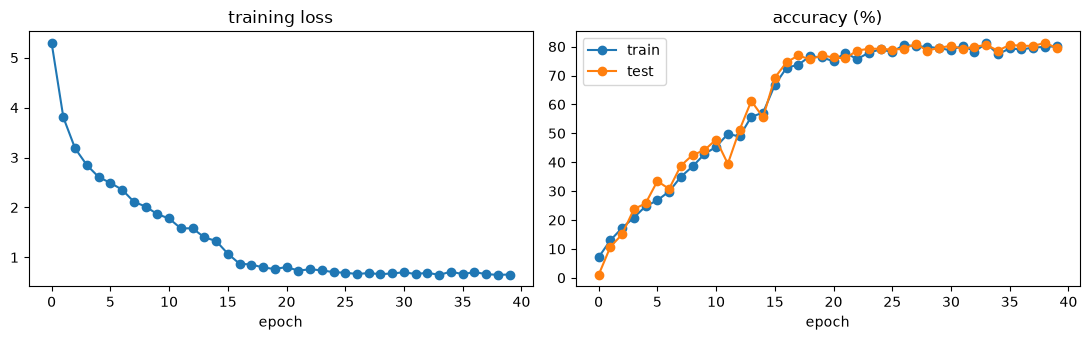

best held-out accuracy: 81.27090301003345 %
random guessing baseline: 0.93% (1 in 107)


In [17]:
plot_history(history)
print("best held-out accuracy:", max(h["test_acc"] for h in history), "%")
print(f"random guessing baseline: {100 / N_CLASSES:.2f}% (1 in {N_CLASSES})")

# Section 5 — Prediction and validation

Three checks, in increasing usefulness:
1. the raw error rate,
2. *which* identities it confuses (confusion matrix),
3. *what* it got wrong (look at the images).

Step 3 is the one that tells you what to fix.

In [18]:
@torch.no_grad()
def predict(model, x):
    """Returns (predicted class, confidence). Softmax turns raw scores into probabilities."""
    model.eval()
    probs = F.softmax(model(x.to(DEVICE)), dim=1)
    conf, pred = probs.max(1)
    return pred.cpu(), conf.cpu()


x, y = next(iter(test_loader))
pred, conf = predict(model, x[:8])
for i in range(8):
    mark = "ok " if pred[i] == y[i] else "XX "
    print(f"{mark} true tiger#{int(y[i])}  predicted tiger#{int(pred[i])}  confidence {conf[i]:.1%}")

ok  true tiger#93  predicted tiger#93  confidence 90.4%
ok  true tiger#93  predicted tiger#93  confidence 87.1%
ok  true tiger#93  predicted tiger#93  confidence 90.8%
ok  true tiger#97  predicted tiger#97  confidence 73.9%
ok  true tiger#97  predicted tiger#97  confidence 67.3%
XX  true tiger#97  predicted tiger#93  confidence 63.8%
ok  true tiger#62  predicted tiger#62  confidence 61.9%
ok  true tiger#62  predicted tiger#62  confidence 75.0%


held-out accuracy 79.60%   error rate 20.40%   misclassified 61


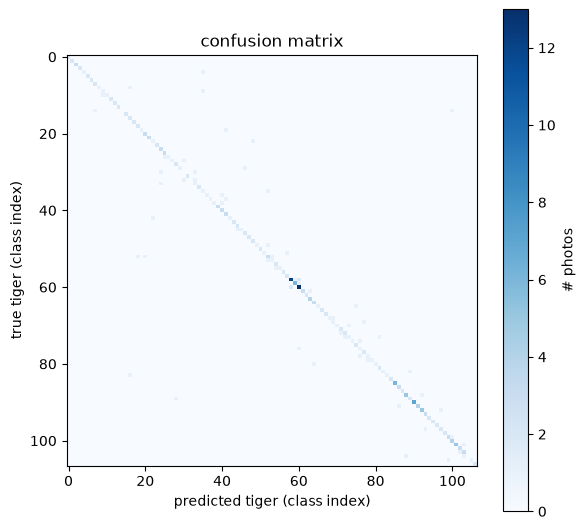

In [19]:
# Full held-out set: accuracy + confusion matrix.
@torch.no_grad()
def evaluate(model, loader, n_classes):
    model.eval()
    cm = torch.zeros(n_classes, n_classes, dtype=torch.long)   # rows = true, cols = predicted
    wrong_x, wrong_true, wrong_pred = [], [], []
    for x, y in loader:
        p = model(x.to(DEVICE)).argmax(1).cpu()
        for t, q in zip(y, p):
            cm[t, q] += 1
        bad = p != y
        if bad.any():
            wrong_x.append(x[bad]); wrong_true.append(y[bad]); wrong_pred.append(p[bad])
    acc = 100.0 * cm.diag().sum().item() / cm.sum().item()
    if wrong_x:
        wrong = (torch.cat(wrong_x), torch.cat(wrong_true), torch.cat(wrong_pred))
    else:
        wrong = (torch.empty(0), torch.empty(0), torch.empty(0))
    return acc, cm, wrong


acc, cm, wrong = evaluate(model, test_loader, N_CLASSES)
print(f"held-out accuracy {acc:.2f}%   error rate {100 - acc:.2f}%   misclassified {len(wrong[0])}")

# 107x107 is too big for per-cell numbers or tick labels, so just show the heatmap: a strong
# diagonal means the network tells tigers apart; scattered off-diagonal mass is the confusion.
fig, ax = plt.subplots(figsize=(6, 5.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xlabel("predicted tiger (class index)"); ax.set_ylabel("true tiger (class index)")
ax.set_title("confusion matrix")
plt.colorbar(im, ax=ax, label="# photos")
plt.tight_layout(); plt.show()

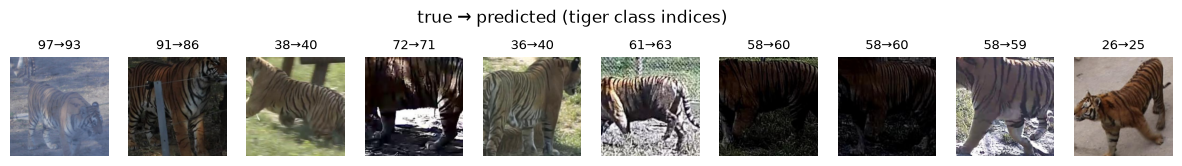

In [20]:
# Look at the mistakes: this is where class-level confusion becomes visible.
n = min(10, len(wrong[0]))
if n:
    fig, axes = plt.subplots(1, n, figsize=(1.5 * n, 2))
    for ax, img, t, p in zip(axes, wrong[0][:n], wrong[1][:n], wrong[2][:n]):
        ax.imshow(unnormalize(img)); ax.set_title(f"{int(t)}→{int(p)}", fontsize=9)
        ax.axis("off")
    plt.suptitle("true → predicted (tiger class indices)"); plt.show()
else:
    print("no mistakes on this run")

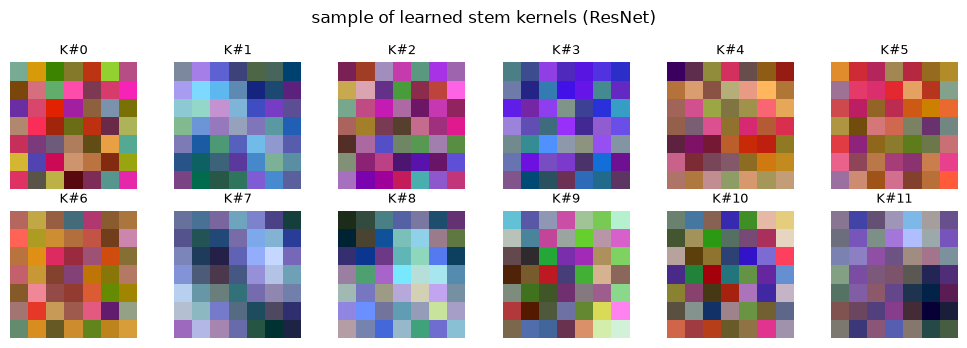

In [21]:
# Visualize stem kernels. Each 7x7x3 tile is one first-layer detector.
k = model.stem[0].weight.detach().cpu()              # (64, 3, 7, 7)
fig, axes = plt.subplots(2, 6, figsize=(10, 3.5))
for i, ax in enumerate(axes.ravel()):
    tile = k[i].permute(1, 2, 0)                     # (7,7,3)
    tile = (tile - tile.min()) / (tile.max() - tile.min() + 1e-8)
    ax.imshow(tile); ax.set_title(f"K#{i}", fontsize=9); ax.axis("off")
plt.suptitle("sample of learned stem kernels (ResNet)")
plt.tight_layout(); plt.show()

# Section 6 — Glossary

**Tensor** — an n-dimensional array. An image batch is a 4-D tensor `(batch, channels, height, width)`.

**Channel / feature map** — one 2-D slice of a layer's output.

**Kernel / filter** — the small grid of weights slid over the input.

**Convolution** — sliding a kernel across the image, computing weighted sums at each position.

**Stride** — how far the kernel moves each step. Larger stride downsamples faster.

**Padding** — extra border pixels used to control output size and edge behavior.

**Batch normalization (BN)** — normalizes activations to stabilize and accelerate optimization.

**Activation (ReLU)** — non-linearity after linear layers.

**Residual block** — a stack of conv layers that learns $F(x)$ and outputs $F(x) + x$.

**Shortcut / skip connection** — path that carries $x$ directly to a later layer.

**Identity shortcut** — shortcut that passes input unchanged when shape matches.

**Projection shortcut** — 1×1 convolution shortcut used when channel count or stride changes.

**Global average pooling** — averages each channel's spatial map to one value.

**Fully connected (dense) layer** — final linear classifier over pooled features.

**Logits** — raw class scores before softmax.

**Softmax** — turns logits into probabilities summing to 1.

**Loss function** — one scalar that measures prediction error. Cross-entropy is used here.

**Gradient** — derivative of loss w.r.t. parameter; direction and magnitude for updates.

**Back-propagation** — chain rule through the network to compute all gradients.

**Optimiser** — update rule that uses gradients to change parameters. Here: SGD with momentum.

**Weight decay** — L2 regularization term that discourages excessively large weights.

**Learning-rate scheduler** — adjusts LR during training (here: step drops at set epochs).

**Epoch** — one full pass over training data. **Batch** — subset processed before one update.

**Training / validation split** — data used to fit vs. held-out data used for evaluation.

**Overfitting** — high training performance but weak held-out performance.

**Confusion matrix** — table of true vs. predicted classes. Off-diagonal mass = mistakes.

**`model.train()` / `model.eval()`** — switches training/inference behavior.

**`zero_grad()`** — clears accumulated gradients before the next backward pass.

**`torch.no_grad()`** — disables gradient tracking during evaluation for speed and memory savings.

## Next steps

Change one thing, re-run `fit`, compare held-out accuracy and epoch time:

| Try | What it tells you |
|---|---|
| increase `BATCH` if GPU memory allows (64 -> 96/128) | whether throughput improves without hurting optimization |
| increase `NUM_WORKERS` | whether data loading is the bottleneck |
| switch to stronger augmentation (`RandomResizedCrop`) | whether generalization improves on difficult IDs |
| train a deeper variant (ResNet-34 style) | whether extra depth helps this dataset |
| use cosine LR schedule | whether optimization smoothness improves final accuracy |
| add label smoothing (`CrossEntropyLoss(label_smoothing=0.1)`) | whether overconfidence is hurting validation |

Change **one** at a time and log the result. That isolates what actually helped.

## Save results

Persist the trained model and validation metrics to `runs/<name>/`, so this run survives a kernel restart and can be compared against the other notebooks later.


In [ ]:
# Save the trained model + validation results into runs/n4_Resnet/, so this run isn't lost.
import json
from pathlib import Path

RUN_DIR = Path("runs") / "n4_Resnet"
RUN_DIR.mkdir(parents=True, exist_ok=True)

torch.save({"model_state": model.state_dict(), "history": history}, RUN_DIR / "model.pt")

with open(RUN_DIR / "metrics.json", "w") as f:
    json.dump({
        "held_out_accuracy": acc,
        "best_test_acc_during_training": max(h["test_acc"] for h in history) if history else None,
        "misclassified": len(wrong[0]),
        "history": history,
    }, f, indent=2)

print("saved model + metrics to", RUN_DIR.resolve())
